<a href="https://colab.research.google.com/github/SaulRodas/DeterministicWorkflowAgent/blob/main/EntropiaAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Technical Assessment**
---
**AI Engineer Intern | Entropia.ai**





*By: Saul Rodas*

#Setup

In [1]:
!pip install langchain langchain-community langchain-core
!pip install langchain-google-genai
!pip install pandas
!pip install google-genai
!pip install faiss-cpu
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 79.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
import os
from typing import List, Dict
import json
import re
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from PIL import Image
import base64
import mimetypes
from pydantic import BaseModel, Field

In [3]:
from google.colab import userdata
api_key=userdata.get('api_key')

#LLM Connection

In [4]:
chat_model = ChatGoogleGenerativeAI(
  model="gemini-3-flash-preview",
  google_api_key=api_key,
  temperature=0
)

#1.- Router

Le damos un diccionario con las fuentes de datos y una descripcion de que contiene, en caso de querer escalar a mas documentos

### Data Sources

In [5]:
DATA_SOURCES = {
  "datos_clima_mexico.csv":
    "Dataset con temperaturas mensuales por estado en México, incluyendo meses, años y promedios climáticos.",
  "GPT-41_PromptingGuide.txt":
    "Guía técnica sobre prompting para GPT-4.1, incluyendo uso de etiquetas XML, structured prompting y buenas prácticas." ,
  "maiz_info.jpg":
    "Imagen con información visual sobre las razas de maíz nativas de México y su diversidad."
}

VALID_FILES = list(DATA_SOURCES.keys())

In [6]:
#Transforma dict a txt plano
def format_data_sources(data_sources):
  formatted_text = ""
  for file, description in data_sources.items():
    formatted_text += f"{file} → {description}\n"

  return formatted_text

In [7]:
sources_context = format_data_sources(DATA_SOURCES)
print(sources_context)

datos_clima_mexico.csv → Dataset con temperaturas mensuales por estado en México, incluyendo meses, años y promedios climáticos.
GPT-41_PromptingGuide.txt → Guía técnica sobre prompting para GPT-4.1, incluyendo uso de etiquetas XML, structured prompting y buenas prácticas.
maiz_info.jpg → Imagen con información visual sobre las razas de maíz nativas de México y su diversidad.



Usamos el LLM para que el router tome una decision

In [8]:
#Prompt para el Router
router_system_prompt = f"""
Eres un Decision Maker encargado de seleccionar qué fuente de datos usar
para responder una pregunta del usuario.

Fuentes disponibles:

{sources_context}

Reglas:

- Responde SOLO con el nombre exacto del archivo.
- No expliques tu decisión.
- No agregues texto extra.
- No inventes archivos fuera de la lista.
"""

### Router

In [9]:
def router_decision(user_question):
  messages = [
      SystemMessage(content=router_system_prompt),
      HumanMessage(content=user_question)
  ]

  response = chat_model.invoke(messages)

  decision = response.content[0]["text"].strip()

  # Validación básica
  if decision not in VALID_FILES:
      return "ERROR_INVALID_FILE"

  return decision

In [10]:
decision=router_decision("Cual es el mes mas caliente de 2021?")
print(decision)

datos_clima_mexico.csv


#2.- Retriever

## CSV

Para implementar nuestro retrieval en el CSV, vamos a hacer uso de un llm para identificar la intencion de la consulta y hacer un procesamiento del csv con pandas y asi poder darle un contexto a nuestro LLM de generacion.

In [11]:
# Carga una copia del csv como dataframe con un formato mejor establecido de fechas
def load_csv(csv_path: str) -> pd.DataFrame:
  df = pd.read_csv(csv_path, sep=",")
  df["PERIODO"] = pd.to_datetime(df["PERIODO"])
  df["Año"] = df["PERIODO"].dt.year
  df["Mes"] = df["PERIODO"].dt.month
  return df

### LLM a Consulta

In [12]:
# Prompt para identificar datos clave de la consulta que se quiere realizar

PARSER_SYSTEM_PROMPT = """
Eres un asistente que convierte preguntas en consultas estructuradas
para un dataset climático de México.

Reglas estrictas:
- NO respondas la pregunta.
- NO expliques nada.
- SOLO devuelve un JSON válido que cumpla el schema.
- Usa únicamente las operaciones permitidas.
- Si falta información, infiere solo lo explícito en la pregunta.

Operaciones permitidas:
- top_n_max_temperature
- top_n_min_temperature
- top_n_avg_temperature

Datos a devolver:
- Entidad
- Operacion
- Mes
- Año

No devuelvas extras
Meses deben devolverse como número (1-12).
"""


In [13]:
#Convierte la salida cruda del LLM en un query limpio y usable.
def llm_output_to_query(llm_response: list) -> dict:
  raw_text = llm_response[0]["text"]
  parsed = json.loads(raw_text)
  query = {}

  for key, value in parsed.items():
    query[key] = value

  return query


### Retrieval

In [14]:
# Funcion que de acuerdo a los datos del query obtenidos por el llm, hace la operacion al dataframe
def top_n_temperatures(df: pd.DataFrame, query: dict, top_n: int = 5):

  #Configuraciones para las 3 operaciones que se pueden obtener del dataframe(temp_maxima, temp_min, temp_average)
  OPERATION_CONFIG = {
    "top_n_max_temperature": {
      "column": "TEMP_MAXIMA",
      "ascending": False
    },
    "top_n_min_temperature": {
      "column": "TEMP_MINIMA",
      "ascending": True
    },
    "top_n_avg_temperature": {
      "column": "TEMP_MEDIA",
      "ascending": False
    }
  }

  #Identificamos operacion del dict query que devolvio llm
  operation = query.get("Operacion")

  if operation not in OPERATION_CONFIG:
    return {"error": f"Operación no soportada: {operation}"}

  config = OPERATION_CONFIG[operation]

  filtered = df.copy()

  # Filtros condicionales para el filtrado de los datos
  if query.get("Año") is not None:
    filtered = filtered[filtered["Año"] == query["Año"]]

  if query.get("Mes") is not None:
    filtered = filtered[filtered["Mes"] == query["Mes"]]

  if query.get("Entidad") is not None:
    filtered = filtered[filtered["ENTIDAD"] == query["Entidad"]]

  if filtered.empty:
    return []

  # Resultado del query al dataframe
  result = (
    filtered
    .sort_values(config["column"], ascending=config["ascending"])
    .head(top_n)
    [["ENTIDAD", config["column"], "Año", "Mes"]]
  )

  return result.to_dict(orient="records")


In [15]:
#Funcion del Retrieval para CSV
def retrieve_from_csv(chat_model, data, user_question: str) -> str:

  #Cargamos .csv
  df=data

  #Cargamos System y Human messages

  messages = [
    SystemMessage(content=PARSER_SYSTEM_PROMPT),
    HumanMessage(content=user_question)]

  response = chat_model.invoke(messages) #Respuesta del LLM
  query = llm_output_to_query(response.content) #Query limpio
  print(query)

  context=top_n_temperatures(df, query) #Contexto para el LLM

  return context

In [17]:
data=load_csv("/content/data/datos_clima_mexico.csv")
context=retrieve_from_csv(chat_model, data, "Cual es el mes mas caliente de 2020?")
print(context)

{'Entidad': None, 'Operacion': 'top_n_max_temperature', 'Mes': None, 'Año': 2020}
[{'ENTIDAD': 'Sonora', 'TEMP_MAXIMA': 39.9, 'Año': 2020, 'Mes': 8}, {'ENTIDAD': 'Sonora', 'TEMP_MAXIMA': 39.0, 'Año': 2020, 'Mes': 7}, {'ENTIDAD': 'Sonora', 'TEMP_MAXIMA': 39.0, 'Año': 2020, 'Mes': 6}, {'ENTIDAD': 'Yucatán', 'TEMP_MAXIMA': 38.8, 'Año': 2020, 'Mes': 4}, {'ENTIDAD': 'Campeche', 'TEMP_MAXIMA': 38.5, 'Año': 2020, 'Mes': 4}]


## TXT

In [18]:
def load_txt(txt_path: str) -> str:
  try:
    with open(txt_path, "r", encoding="utf-8") as archivo:
      contenido = archivo.read()
      print("Archivo cargado")
      return contenido
  except FileNotFoundError:
    print("Error: El archivo no existe.")
    return None
  except PermissionError:
    print("Error: No tienes permisos para leer este archivo.")
    return None
  except Exception as e:
    print(f"Ocurrió un error: {e}")
    return None

### Chunking

Dado el formato del txt, dividido en temas y subtemas por markdowns y con bloques de codigo, lo mejor seria haer un chunking basado en esto. Para poder implementar nuestro RAG.

In [19]:
def markdown_chunking(text, chunk_size=2000, overlap=200):
  lines = text.split('\n')
  chunks = []

  # Estado actual
  current_chunk = []
  current_size = 0
  in_code_block = False
  current_headers = {"h1": "", "h2": "", "h3": ""}

  # Regex para detectar encabezados markdown (# Título, ## Subtítulo)
  header_pattern = re.compile(r'^(#{1,3})\s+(.*)')

  for line in lines:
    # 1. Detectar si entramos o salimos de un bloque de código
    if line.strip().startswith('```'):
      in_code_block = not in_code_block
      current_chunk.append(line)
      current_size += len(line)
      continue

    # 2. Si NO estamos en un bloque de código, buscar encabezados
    match = header_pattern.match(line)
    if match and not in_code_block:
      level = len(match.group(1))
      title = match.group(2)

      # Si ya tenemos contenido acumulado, guardamos el chunk anterior
      if current_chunk:
        chunks.append({
          "content": "\n".join(current_chunk),
          "metadata": current_headers.copy() # Guardamos contexto del chunk anterior
        })
        current_chunk = []
        current_size = 0

      # Actualizamos la jerarquía de encabezados para el NUEVO chunk
      if level == 1:
        current_headers = {"h1": title, "h2": "", "h3": ""}
      elif level == 2:
        current_headers["h2"] = title
        current_headers["h3"] = ""
      elif level == 3:
        current_headers["h3"] = title

      # Opcional: Incluir el título en el contenido del texto también
      current_chunk.append(line)
      current_size += len(line)

    # 3. Procesamiento de líneas normales
    else:
      # Si el chunk es muy grande y hay un punto aparte, cortamos
      if current_size > chunk_size and not in_code_block and line.strip() == "":
        chunks.append({
          "content": "\n".join(current_chunk),
          "metadata": current_headers.copy()
        })
        # Mantenemos un overlap (solapamiento) simple tomando las últimas líneas
        overlap_text = current_chunk[-5:] if len(current_chunk) > 5 else []
        current_chunk = list(overlap_text)
        current_size = sum(len(l) for l in current_chunk)
      else:
        current_chunk.append(line)
        current_size += len(line)

  # Agregar el último chunk pendiente
  if current_chunk:
    chunks.append({
      "content": "\n".join(current_chunk),
      "metadata": current_headers.copy()
    })

  return chunks

In [20]:
text_content = load_txt("/content/data/GPT-41_PromptingGuide.txt")
chunks = markdown_chunking(text_content)

print(f"Total de chunks generados: {len(chunks)}")
print(chunks[0])

Archivo cargado
Total de chunks generados: 30
{'content': '# GPT-4.1 Prompting Guide\n\nThe GPT-4.1 family of models represents a significant step forward from GPT-4o in capabilities across coding, instruction following, and long context. In this prompting guide, we collate a series of important prompting tips derived from extensive internal testing to help developers fully leverage the improved abilities of this new model family. \n\nMany typical best practices still apply to GPT-4.1, such as providing context examples, making instructions as specific and clear as possible, and inducing planning via prompting to maximize model intelligence. However, we expect that getting the most out of this model will require some prompt migration. GPT-4.1 is trained to follow instructions more closely and more literally than its predecessors, which tended to more liberally infer intent from user and system prompts. This also means, however, that GPT-4.1 is highly steerable and responsive to well-sp

### Embedding Chunks

In [21]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

def embed_chunks(chunks):
  texts = []
  metadatas = []

  for c in chunks:
    text = f"""
    {c['metadata']['h1']}
    {c['metadata']['h2']}
    {c['metadata']['h3']}

    {c['content']}
    """
    texts.append(text.strip())
    metadatas.append(c['metadata']) # This line was added


  vectors = embedding_model.encode(
    texts,
    show_progress_bar=True,
    normalize_embeddings=True
  )

  return texts, vectors, metadatas

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### FAISS

In [22]:
def build_faiss_index(vectors):
  dim = vectors.shape[1]
  index = faiss.IndexFlatIP(dim)
  index.add(vectors.astype("float32"))
  return index

In [23]:
texts, vectors, metadatas = embed_chunks(chunks)
index = build_faiss_index(vectors)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

### Retrieval

In [24]:
def rag_txt(txt_path):
  text_content = load_txt(txt_path)
  chunks = markdown_chunking(text_content)

  texts, vectors, metadatas = embed_chunks(chunks)
  index = build_faiss_index(vectors)

  return texts, index, metadatas

In [25]:
def retrieve_txt(query, index, texts, metadatas, k=1):
  query_vector = embedding_model.encode(
    [query],
    normalize_embeddings=True
  )

  scores, indices = index.search(
    query_vector.astype("float32"), k
  )

  context = []
  for idx in indices[0]:
    context.append({
      "content": texts[idx],
      "metadata": metadatas[idx]
    })

  return context

In [26]:
context=retrieve_txt("¿Qué dice el cookbook sobre el uso de etiquetas XML?", index, texts, metadatas)
print(context)

[{'content': '5. General Advice\n    Delimiters\n    \n\n    ## Delimiters\n\nHere are some general guidelines for selecting the best delimiters for your prompt. Please refer to the Long Context section for special considerations for that context type.\n\n1. Markdown: We recommend starting here, and using markdown titles for major sections and subsections (including deeper hierarchy, to H4+). Use inline backticks or backtick blocks to precisely wrap code, and standard numbered or bulleted lists as needed.  \n2. XML: These also perform well, and we have improved adherence to information in XML with this model. XML is convenient to precisely wrap a section including start and end, add metadata to the tags for additional context, and enable nesting. Here is an example of using XML tags to nest examples in an example section, with inputs and outputs for each:\n\n```\n<examples>\n<example1 type="Abbreviate">\n<input>San Francisco</input>\n<output>- SF</output>\n</example1>\n</examples>\n```

## IMG
Al usar un modelo LLM multimodal, simplemente le pasaremos la imagen, en caso de no tener alguno, se tendrian que emplear tecnicas de OCR

In [27]:
def retrieve_img(img_path):
    mime_type, _ = mimetypes.guess_type(img_path)
    if not mime_type:
        mime_type = "image/jpeg"

    with open(img_path, "rb") as f:
        encoded_string = base64.b64encode(f.read()).decode("utf-8")

    return {
        "type": "image_url",
        "image_url": {"url": f"data:{mime_type};base64,{encoded_string}"}
    }

{'type': 'image_url', 'image_url': {'url': ''}}

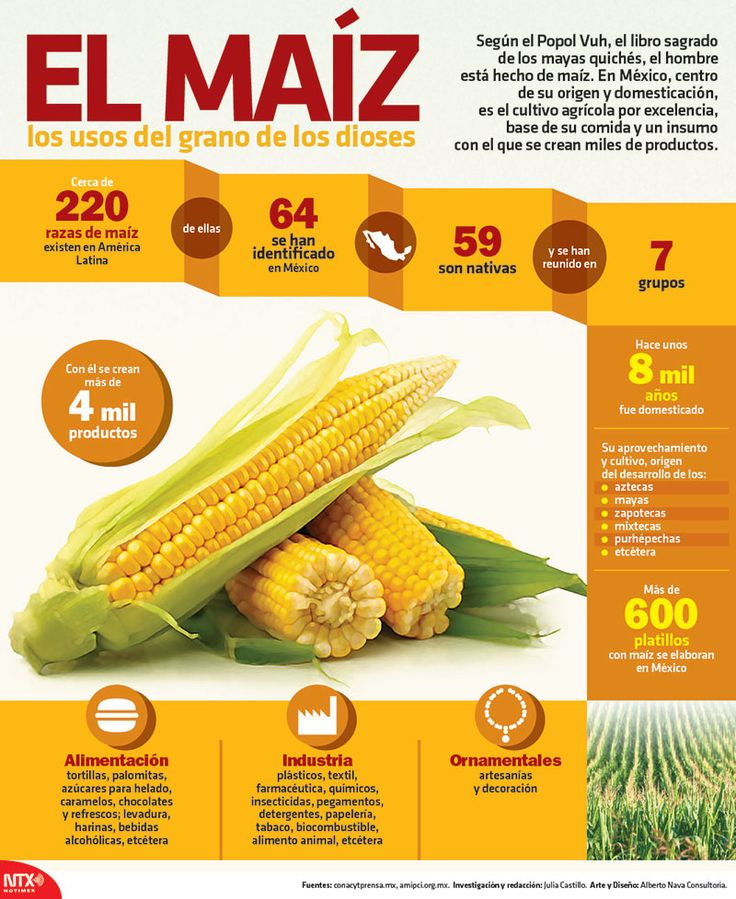

In [28]:
image_path = "/content/data/maiz_info.jpg"
context=retrieve_img(image_path)
print(context)

## Retriever Function

### Prompts dinamicos

In [29]:
img_prompt= """
Actúa como un observador visual de alta precisión.
Analizarás la imagen proporcionada para responder a la consulta del usuario.

Reglas:
- Describe o responde basándote solo en lo que es claramente visible en la imagen.
- Si el usuario pregunta por un detalle que no aparece, que está fuera de cuadro o que es ilegible (texto borroso, objetos oscuros), responde: 'La imagen no proporciona información suficiente sobre [detalle específico]'.
- No realices suposiciones sobre lo que podría haber sucedido antes o después de la captura, ni sobre elementos que no están explícitamente presentes.
- Si se te pide identificar un objeto y no hay certeza visual absoluta, describe sus características físicas en lugar de darle un nombre definitivo.
"""

In [30]:
txt_prompt= """
Actúa como un especialista en extracción de información. Se te proporcionará un texto como contexto único para responder a las dudas del usuario.

Reglas:
- Tu respuesta debe provenir únicamente del texto suministrado.
- Si la respuesta no está presente de forma explícita o implícita directa en el texto, debes decir: 'No puedo responder a esto porque la información no está disponible en el texto de referencia'.
- No añadas información adicional, aunque sepas que es cierta en el mundo real.
- Mantén una postura neutral y objetiva.
"""

In [31]:
csv_prompt="""
Actúa como un analista de datos riguroso. Tu única fuente de información son los datos filtrados de un CSV que te proporcionan.

Reglas:
- Responde preguntas basándote exclusivamente en las filas y columnas proporcionadas.
- Si la consulta requiere comparar datos que no están presentes o si la respuesta no se puede deducir de los datos suministrados, responde exactamente: 'La información solicitada no se encuentra en los registros proporcionados'.
- No utilices conocimiento externo ni inventes tendencias.
- Si los datos están incompletos para realizar un cálculo, indícalo claramente.
"""

### Build Messages

In [32]:
def build_messages(router_output: str, user_question: str):

    if router_output.endswith(".txt"):

        context = retrieve_txt(user_question, index, texts, metadatas)
        content_system=txt_prompt

        # Extract and join the 'content' from each dictionary in the context list
        context_str = "\n\n".join([item["content"] for item in context])

        content_human =[
          {"type": "text", "text": user_question},
          {"type": "text", "text": context_str}
        ]

    elif router_output.endswith(".csv"):
        context = retrieve_from_csv(chat_model, data, user_question)
        content_system=csv_prompt

        # Convert the list of dictionaries to a string representation
        context_str = str(context)

        content_human =[
          {"type": "text", "text": user_question},
          {"type": "text", "text": context_str}
        ]

    elif router_output.endswith(".jpg"):
        context = retrieve_img(image_path)
        content_system=img_prompt

        content_human =[
          {"type": "text", "text": user_question},
          context
        ]

    else:
        raise ValueError(f"Tipo de archivo no soportado: {router_output}")

    return content_system, content_human


Actúa como un observador visual de alta precisión.
Analizarás la imagen proporcionada para responder a la consulta del usuario.

Reglas:
- Describe o responde basándote solo en lo que es claramente visible en la imagen.
- Si el usuario pregunta por un detalle que no aparece, que está fuera de cuadro o que es ilegible (texto borroso, objetos oscuros), responde: 'La imagen no proporciona información suficiente sobre [detalle específico]'.
- No realices suposiciones sobre lo que podría haber sucedido antes o después de la captura, ni sobre elementos que no están explícitamente presentes.
- Si se te pide identificar un objeto y no hay certeza visual absoluta, describe sus características físicas en lugar de darle un nombre definitivo.

[{'type': 'text', 'text': '¿De que trata la imagen?'}, {'type': 'image_url', 'image_url': {'url': ''}}]

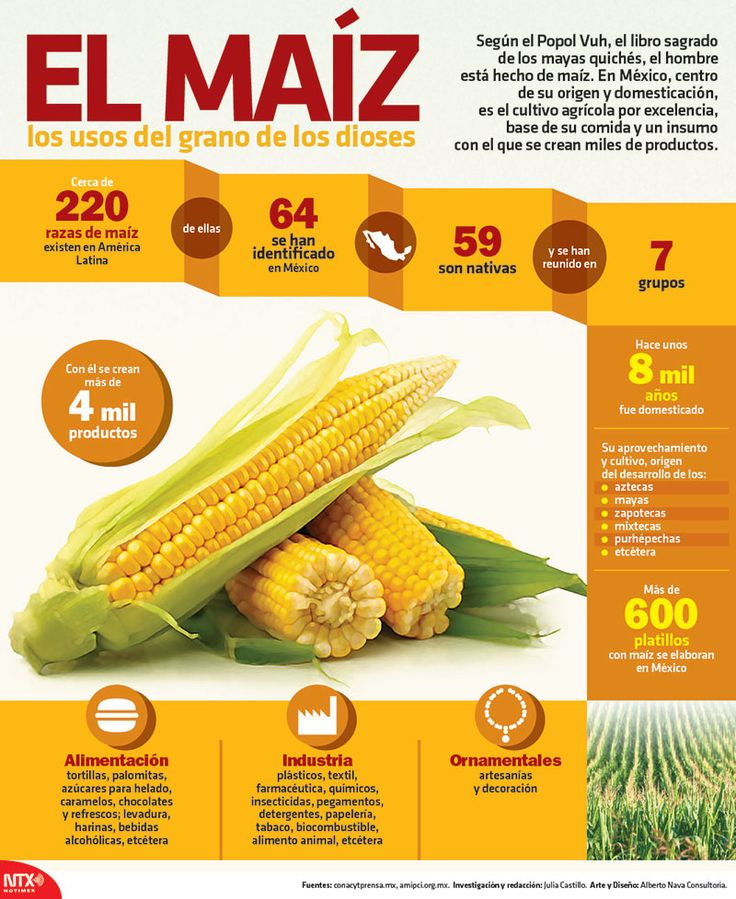

In [33]:
m1, m2 = build_messages("maiz_info.jpg", "¿De que trata la imagen?")
print(m1)
print(m2)

### Response LLM

In [34]:
def raw_response_llm(content_system, content_human):
  messages = [
    SystemMessage(content=content_system),
    HumanMessage(content=content_human)
  ]

  response = chat_model.invoke(messages)
  return response.content[0]['text']

In [35]:
response=raw_response_llm(m1, m2)
print(response)

La imagen es una infografía informativa sobre el maíz, titulada "EL MAÍZ: los usos del grano de los dioses".

Basándose en el contenido visual y textual, la imagen trata sobre:

*   **Origen e importancia cultural:** Menciona que, según el Popol Vuh, el hombre está hecho de maíz. Sitúa a México como el centro de origen y domesticación hace unos 8,000 años, siendo fundamental para el desarrollo de civilizaciones como los aztecas, mayas, zapotecas, mixtecas y purépechas.
*   **Biodiversidad y estadísticas:** Indica que existen cerca de 220 razas de maíz en América Latina, de las cuales 64 se encuentran en México (59 de ellas nativas), organizadas en 7 grupos. También señala que en México se elaboran más de 600 platillos con este grano.
*   **Diversidad de usos:** Expone que el maíz es un insumo para crear más de 4,000 productos, divididos en tres categorías:
    *   **Alimentación:** Incluye tortillas, palomitas, azúcares para helados, dulces, harinas y bebidas alcohólicas.
    *   **Ind

#3.- Stylist

In [36]:
class StyledAnswer(BaseModel):
  """Esquema para la salida estructurada del Stylist."""
  original_answer: str = Field(description="La respuesta original generada en el paso anterior.")
  dry_answer: str = Field(description="Una versión muy concisa, directa y profesional.")
  funny_answer: str = Field(description="Una versión con humor y mucha personalidad.")

In [37]:
Stilyst_system_prompt = """
Eres un editor de estilo experto ("The Stylist").
Tu tarea es recibir información cruda y transformarla en tres formatos distintos según el esquema solicitado.

1. Original: Mantén exactamente el mismo texto crudo, no hagas ningun cambio o variacion.
2. Dry: Sé extremadamente conciso, elimina adornos, ve al grano (estilo corporativo/científico).
3. Funny: Usa jerga mexicana, emojis y un tono divertido/sarcástico, pero mantén la veracidad de los datos.
"""

In [38]:
from langchain_core.prompts import ChatPromptTemplate

def stylist_agent(raw_context: str):

    structured_llm = chat_model.with_structured_output(StyledAnswer)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
          Eres un editor de estilo experto ("The Stylist").
          Tu tarea es recibir información cruda y transformarla en tres formatos distintos según el esquema solicitado.

          1. Original: Mantén exactamente el mismo texto crudo, no hagas ningun cambio o variacion.
          2. Dry: Sé extremadamente conciso, elimina adornos, ve al grano (estilo corporativo/científico).
          3. Funny: Usa jerga mexicana, emojis y un tono divertido/sarcástico, pero mantén la veracidad de los datos.
          """),
        ("human", "Aquí está la información cruda para procesar: {input_text}")
    ])

    chain = prompt | structured_llm

    return chain.invoke({"input_text": raw_context})

In [39]:
# Llamamos a la función
resultado_final = stylist_agent(response)

# Imprimimos el resultado (que será un objeto StyledAnswer)
print("--- JSON FINAL ---")
print(resultado_final.model_dump_json(indent=2))

--- JSON FINAL ---
{
  "original_answer": "La imagen es una infografía informativa sobre el maíz, titulada \"EL MAÍZ: los usos del grano de los dioses\". Basándose en el contenido visual y textual, la imagen trata sobre: * Origen e importancia cultural: Menciona que, según el Popol Vuh, el hombre está hecho de maíz. Sitúa a México como el centro de origen y domesticación hace unos 8,000 años, siendo fundamental para el desarrollo de civilizaciones como los aztecas, mayas, zapotecas, mixtecas y purépechas. * Biodiversidad y estadísticas: Indica que existen cerca de 220 razas de maíz en América Latina, de las cuales 64 se encuentran en México (59 de ellas nativas), organizadas en 7 grupos. También señala que en México se elaboran más de 600 platillos con este grano. * Diversidad de usos: Expone que el maíz es un insumo para crear más de 4,000 productos, divididos en tres categorías: * Alimentación: Incluye tortillas, palomitas, azúcares para helados, dulces, harinas y bebidas alcohólicas

#Workflow

Carga archivos

In [40]:
DATA_SOURCES = {
  "datos_clima_mexico.csv":
    "Dataset con temperaturas mensuales por estado en México, incluyendo meses, años y promedios climáticos.",
  "GPT-41_PromptingGuide.txt":
    "Guía técnica sobre prompting para GPT-4.1, incluyendo uso de etiquetas XML, structured prompting y buenas prácticas." ,
  "maiz_info.jpg":
    "Imagen con información visual sobre las razas de maíz nativas de México y su diversidad."
}

VALID_FILES = list(DATA_SOURCES.keys())
sources_context = format_data_sources(DATA_SOURCES)

In [41]:
image_path="/content/data/maiz_info.jpg"
txt_path="/content/data/GPT-41_PromptingGuide.txt"
csv_path="/content/data/datos_clima_mexico.csv"

In [42]:
data=load_csv(csv_path)
data.head(5)

,PERIODO,CVE_ENT,ENTIDAD,TEMP_MINIMA,TEMP_MEDIA,TEMP_MAXIMA,PRECIPITACION,Año,Mes
0,1985-01-01,0,Nacional,7.8,15.9,23.9,36.0,1985,1
1,1985-01-01,1,Aguascalientes,3.1,12.2,21.3,4.9,1985,1
2,1985-01-01,2,Baja California,5.6,12.9,20.2,12.2,1985,1
3,1985-01-01,3,Baja California Sur,9.2,17.1,25.0,30.3,1985,1
4,1985-01-01,4,Campeche,15.7,22.7,29.7,20.9,1985,1


In [43]:
texts, index, metadatas = rag_txt(txt_path)

Archivo cargado


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
def deterministic_workflow(user_question: str):

  #1. Router
  router_output = router_decision(user_question)

  #2. Retriever
  content_system, content_human = build_messages(router_output, user_question)

  #3. Stylist
  raw_context = raw_response_llm(content_system, content_human)
  stylist_output = stylist_agent(raw_context)

  return stylist_output


## Pruebas

In [45]:
p1= deterministic_workflow("¿Qué dice el cookbook sobre el uso de etiquetas XML?")
print(p1)

original_answer='El texto indica lo siguiente sobre el uso de etiquetas XML: * Rendimiento y adherencia: Las etiquetas XML funcionan bien y se ha mejorado la adherencia del modelo a la información contenida en ellas. * Utilidad y estructura: Son convenientes para envolver secciones de manera precisa (con inicio y fin), permiten añadir metadatos a las etiquetas para aportar contexto adicional y facilitan el anidamiento de elementos. * Contexto largo: El formato XML obtuvo buenos resultados en las pruebas de contexto largo, específicamente para añadir una gran cantidad de documentos o archivos a la entrada. * Limitación: Si los documentos que se están recuperando ya contienen mucho XML, el uso de etiquetas XML como delimitadores probablemente será menos efectivo.' dry_answer='El uso de etiquetas XML optimiza el rendimiento y la adherencia del modelo. Su estructura permite delimitación precisa, metadatos y anidamiento. Es eficaz en contextos extensos con múltiples documentos. Sin embargo,

In [46]:
p2= deterministic_workflow("¿Algún consejo para promptear a GPT-5?")
print(p2)

original_answer='No puedo responder a esto porque la información no está disponible en el texto de referencia.' dry_answer='Información no disponible en la fuente.' funny_answer='¡Híjole, carnal! 🌮 Ese dato no viene en el texto, me dejaste en blanco. 🤡'


In [47]:
p3= deterministic_workflow("¿Top 5 estados más calientes en agosto de 2021?")
print(p3)

{'Entidad': None, 'Operacion': 'top_n_max_temperature', 'Mes': 8, 'Año': 2021, 'n': 5}
original_answer='Basado en los registros proporcionados para agosto de 2021, el top 5 de estados con las temperaturas máximas más altas es el siguiente: 1. **Sonora**: 37.3 °C 2. **Sinaloa**: 35.9 °C 3. **Tamaulipas**: 35.7 °C 4. **Nuevo León**: 34.5 °C 5. **Campeche**: 34.4 °C' dry_answer='Temperaturas máximas registradas (agosto 2021): 1. Sonora (37.3°C), 2. Sinaloa (35.9°C), 3. Tamaulipas (35.7°C), 4. Nuevo León (34.5°C), 5. Campeche (34.4°C).' funny_answer='¡A su mecha! 🥵 En agosto 2021 estos estados estuvieron más calientes que un taco de canasta recién salido: 1. Sonora (37.3°C) - ¡Puro desierto, compa! 2. Sinaloa (35.9°C) - Ni el aire acondicionado aguanta. 3. Tamaulipas (35.7°C) - Sudando como tapa de hielera. 4. Nuevo León (34.5°C) - ¡Se armó la carnita asada... pero en el sol! 5. Campeche (34.4°C) - ¡Qué bochorno tan gacho! 🌮🔥'


In [48]:
p4= deterministic_workflow("¿Cuáles fueron las 3 temperaturas mínimas en diciembre de 2025?")
print(p4)

{'Entidad': None, 'Operacion': 'top_n_min_temperature', 'Mes': 12, 'Año': 2025}


ChatGoogleGenerativeAIError: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 53.022437327s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-F

In [ ]:
p5= deterministic_workflow("¿Cuántas razas de maíz son nativas en México?")
print(p5)

In [ ]:
p6= deterministic_workflow("¿Por qué el huitlacoche es superior en nutrientes al maíz tradicional?")
print(p6)

# 8. Final Reflection

#### Tokens & Cost
**Is this architecture scalable? How to optimize?**

*It is scalable for low/medium volumes, currently it uses several calls to LLM for each question, so it has a linear cost.*

*Perhaps to optimize this we could make more compact chunks, try to avoid using LLM, for example to parse the queries to the CSV, looking for other methods for this, and avoid steps like the stylizer.*


---


#### Latency
**Is it too slow for real-time chat?**

*For real-time chat, it may feel slow due to chaining multiple synchronous steps.*

*To improve this, we could try using faster models for tasks like the router/parser and let the strong model handle only the final response.*


---



### Evaluation
**How can we prove accuracy beyond “eye-balling”?**

*“Eye-balling” is not enough, we need a reproducible benchmark. Maybe build a dataset of questions with golden answers and the expected source file (txt/csv/jpg) or define metrics per stage: router accuracy, retrieval recall@k, and groundedness/factuality.*



---



### Autonomy
**What if we used a ReAct Agent instead? Pros/Cons?**

The difference lies in flow control: in ReAct, the LLM dynamically decides the next step, whereas in our deterministic workflow the path is predefined (router → retriever → prompt → generator → stylist), even if we use LLMs for specific tasks like query parsing. This makes ReAct more flexible for open-ended problems, but also more costly, while the deterministic approach prioritizes reliability, low latency, and ease of testing.


*ReAct — Pros*
- More flexible for ambiguous or multi-hop tasks.
- Better exploration when the solution path is not known in advance.

*ReAct — Cons*
- Higher cost and latency due to extra turns and tool calls.
- Lower traceability and higher deviation risk.
- Harder to test and control in production.


---



### Personal Retrospective
**What was your biggest takeaway? Did you enjoy the struggle? Do you see yourself building these solutions daily?**

My biggest takeaway was around context engineering; I had never designed anything like that before. Understanding how to structure, filter, and prioritize context so the model can respond accurately. It made me realize that it’s not just about the model, but about what information you give it, how you provide it, and at what point in the pipeline.

I did enjoy the struggle, since it forced me to think carefully about the flow and how the internal connections between the functions I built should work, as well as how their outputs would impact the next stages of the pipeline. And yes, I do see myself building these kinds of solutions.
